# Introduction

This notebook explores the relationship between education and economic development in Kyrgyzstan using data from 2011 to 2024. Data collection and cleaning are covered in the previous notebook, `01-cleaning.ipynb`.

The main goal is to identify patterns and correlations between key education indicators — expenditure, graduates, teachers, and institutions — and economic indicators such as GDP per capita, employment, salaries, and industrial production.

# Table of Contents

1. [Introduction](#introduction)
2. [Importing Libraries & Loading Data](#importing-libraries--loading-data)
3. [Dataset Description](#dataset-description)
4. [Research Questions](#research-questions)
5. [Descriptive Statistics](#descriptive-statistics)
6. [Visualizations](#visualizations)
   - [Time Series Plots](#time-series-plots)
   - [Composition of Education Expenditure by Level](#composition-of-education-expenditure-by-level)
   - [Education Expenditure vs. GDP per Capita](#education-expenditure-vs-gdp-per-capita)
   - [Education Expenditure vs. Graduates with Cost per Graduate as Bubble Size](#education-expenditure-vs-graduates-with-cost-per-graduate-as-bubble-size)
   - [Graduates vs. Unemployment Rate & Employed Population](#graduates-vs-unemployment-rate--employed-population)
7. [Correlation Analysis](#correlation-analysis)
8. [Hypothesis Test](#hypothesis-test)
9. [Interpretation of Findings](#interpretation-of-findings)
10. [Limitations](#limitations)
11. [Conclusion](#conclusion)

---

# Importing Libraries & Loading Data

In [575]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# configuration
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [576]:
df = pd.read_csv('data/final_dataset.csv', index_col='year')

# Dataset Description

In [577]:
df.head()

,birth_count,employed_population,gdp_per_capita,monthly_salary,unemployment_rate,industrial_production,inst_preschool,inst_general_school,inst_elementary,inst_junior,...,grad_vocational,grad_secondary_special,grad_higher,edu_exp_total,edu_exp_preschool,edu_exp_secondary,edu_exp_higher,inst_total,teachers_total,grad_total
year,,,,,,,,,,,,,,,,,,,,,
2011,149612,2277693,54400,9304,0.09,164361100000.00,741,2204,125,202,...,28100,15500,41800,19420400000,1650700000,12574600000,2442400000,5438,102104,243000
2012,154918,2286400,58000,10726,0.08,137229200000.00,819,2201,118,222,...,25400,16400,41700,22925900000,2153200000,14956600000,2757100000,5517,103102,233800
2013,155520,2263000,65000,11341,0.08,169829400000.00,927,2207,115,202,...,27500,17900,41300,24089700000,2576500000,14852100000,3078100000,5637,103953,231600
2014,161813,2302704,71800,12285,0.08,171108900000.00,1062,2205,115,203,...,25500,23000,40800,25915400000,2948800000,15102600000,3412300000,5755,102660,230700
2015,163452,2352100,75500,13483,0.08,181026700000.00,1186,2218,115,200,...,25700,27100,41700,29995000000,3721600000,16997200000,3854200000,5905,106125,237000


In [578]:
df.shape

(14, 33)

In [579]:
df.columns.tolist()

['birth_count',
 'employed_population',
 'gdp_per_capita',
 'monthly_salary',
 'unemployment_rate',
 'industrial_production',
 'inst_preschool',
 'inst_general_school',
 'inst_elementary',
 'inst_junior',
 'inst_high',
 'inst_special_needs',
 'inst_vocational',
 'inst_secondary_special',
 'inst_higher',
 'teachers_preschool',
 'teachers_general_school',
 'teachers_special_needs',
 'teachers_vocational',
 'teachers_secondary_special',
 'teachers_higher',
 'grad_secondary_9',
 'grad_secondary_11',
 'grad_vocational',
 'grad_secondary_special',
 'grad_higher',
 'edu_exp_total',
 'edu_exp_preschool',
 'edu_exp_secondary',
 'edu_exp_higher',
 'inst_total',
 'teachers_total',
 'grad_total']

The dataset contains *14 observations* and *33 features*, covering socio-economic and education-related indicators.

- **birth_count** — number of births per year  
- **employed_population** — total employed population  
- **gdp_per_capita** — GDP per capita (som)
- **monthly_salary** — average monthly salary  
- **unemployment_rate** — unemployment rate (%)  
- **industrial_production** — industrial production output (som) 

> `inst_` — number of educational institutions by level  
- **inst_preschool** — preschool institutions  
- **inst_general_school** — general education schools  
- **inst_elementary** — elementary schools (grades 1–4)  
- **inst_junior** — lower secondary schools (grades 5–9)  
- **inst_high** — upper secondary schools (grades 10–11)  
- **inst_special_needs** — institutions for students with special needs  
- **inst_vocational** — vocational schools  
- **inst_secondary_special** — secondary specialized institutions  
- **inst_higher** — higher education institutions (universities)  

> `teachers_` — number of teachers in the corresponding institutions  
- **teachers_preschool** — preschool teachers  
- **teachers_general_school** — teachers in general schools  
- **teachers_special_needs** — teachers in special needs institutions  
- **teachers_vocational** — vocational education teachers  
- **teachers_secondary_special** — teachers in secondary specialized institutions  
- **teachers_higher** — university teachers  

> `grad_` — number of graduates by education level  
- **grad_secondary_9** — graduates of grade 9  
- **grad_secondary_11** — graduates of grade 11  
- **grad_vocational** — vocational program graduates  
- **grad_secondary_special** — graduates of secondary specialized institutions  
- **grad_higher** — higher education graduates

> `edu_exp` - amount of state budget expenditures by level
- **edu_exp_preschool** - expenditures on preschool education
- **edu_exp_secondary** - expenditures on secondary education
- **edu_exp_higher** - expenditures on higher education

> Aggregated features
- **inst_total** — total number of educational institutions across all levels  
- **teachers_total** — total number of teachers across all institution types  
- **grad_total** — total number of graduates across all education levels
- **edu_exp_total** - total amount of state budget expenditures on education

# Research Questions

- How have key education and economy indicators in Kyrgyzstan changed between 2011 and 2024?

- Is there a statistically significant association between education indicators and economy indicators in Kyrgyzstan?

- Can education spending be considered a direct cause of economic growth in Kyrgyzstan?

- What is the most plausible explanation for the relationship between education and economic development in Kyrgyzstan?

# Descriptive Statistics

In [580]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
birth_count,14.00,156187.50,9163.68,140419.00,150179.25,155219.00,160899.75,173484.00
employed_population,14.00,2428456.93,151687.05,2263000.00,2314828.00,2373100.00,2514725.00,2756000.00
gdp_per_capita,14.00,103300.00,48989.45,54400.00,72725.00,88850.00,110525.00,219200.00
monthly_salary,14.00,18126.86,7992.76,9304.00,12584.50,16048.50,19232.50,36047.00
unemployment_rate,14.00,0.06,0.02,0.04,0.05,0.07,0.08,0.09
industrial_production,14.00,288460821992.86,140590380190.12,137229200000.00,173588350000.00,247286900000.00,359172875000.00,599755200000.00
inst_preschool,14.00,1402.71,410.32,741.00,1093.00,1443.50,1696.00,1997.00
inst_general_school,14.00,2273.64,67.43,2201.00,2209.75,2263.50,2323.75,2394.00
inst_elementary,14.00,126.36,7.82,115.00,119.00,130.00,132.75,135.00
inst_junior,14.00,208.21,14.76,192.00,199.25,202.00,219.00,242.00


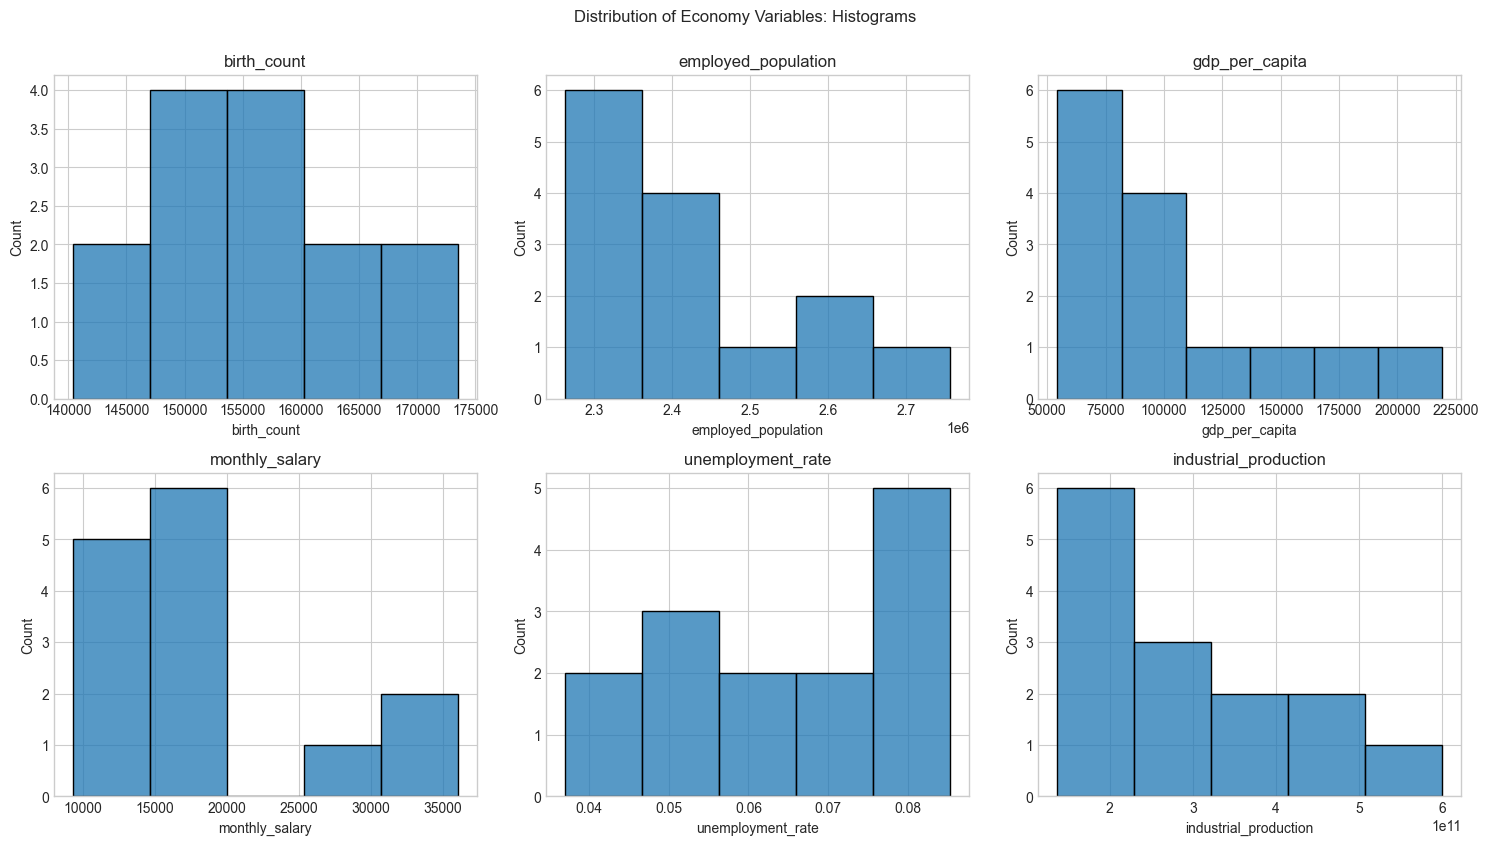

In [581]:
economy_cols = [
    'birth_count', 
    'employed_population', 
    'gdp_per_capita', 
    'monthly_salary', 
    'unemployment_rate', 
    'industrial_production'
]

plt.figure(figsize=(15, 12))
for i, col in enumerate(economy_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[col])
    plt.title(col)
plt.suptitle('Distribution of Economy Variables: Histograms', y=1)
plt.tight_layout()
plt.show()

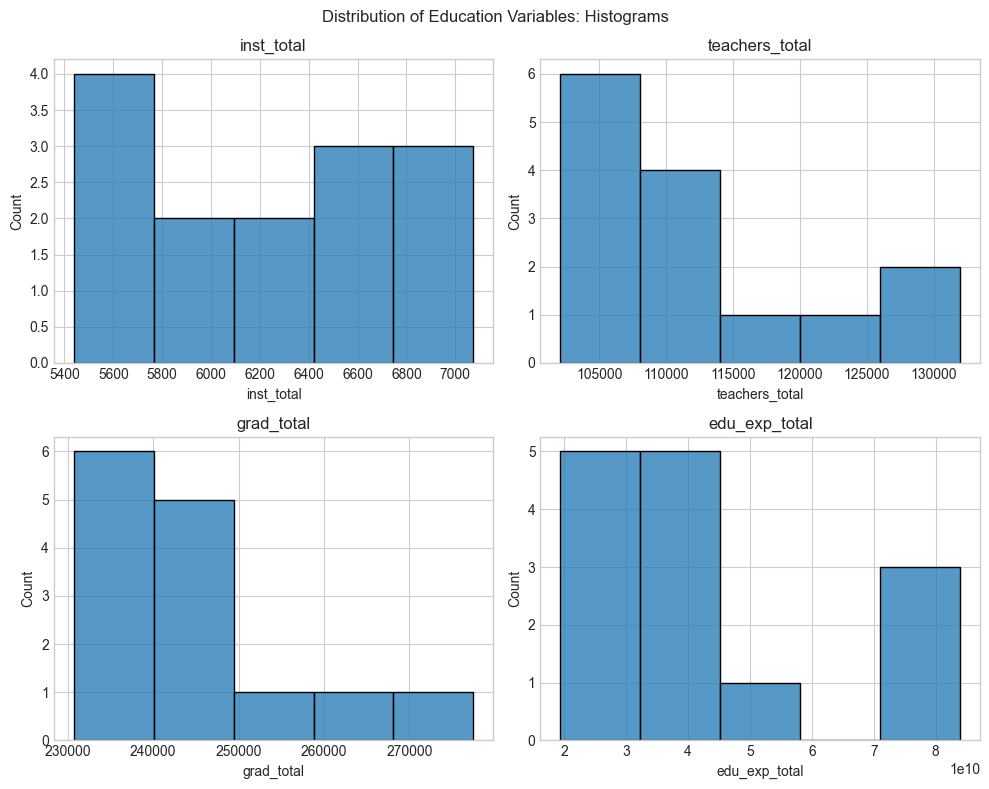

In [582]:
education_cols = [
    'inst_total', 
    'teachers_total', 
    'grad_total',
    'edu_exp_total'
]

plt.figure(figsize=(10, 8))
for i, col in enumerate(education_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(x=df[col])
    plt.title(col)
plt.suptitle('Distribution of Education Variables: Histograms')
plt.tight_layout()
plt.show()

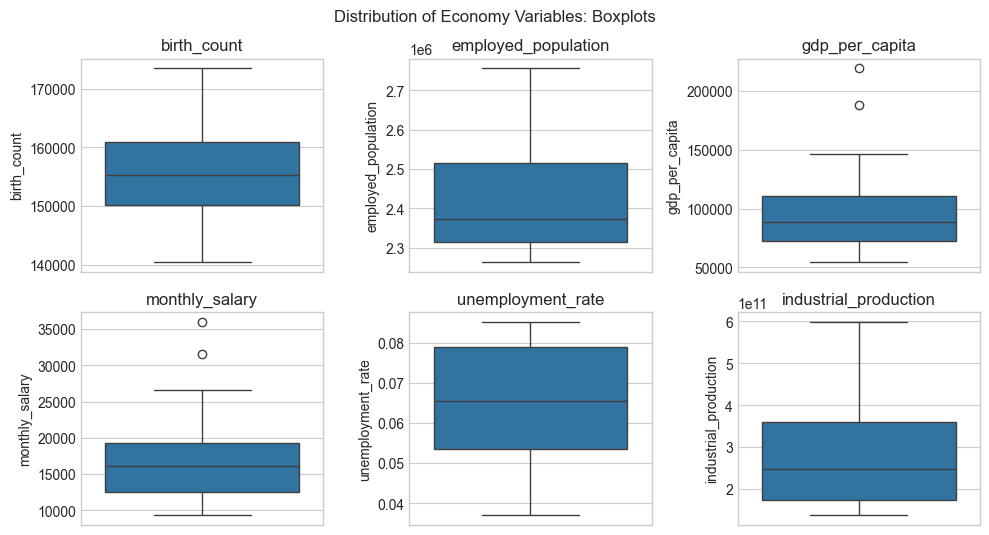

In [583]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(economy_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle('Distribution of Economy Variables: Boxplots')
plt.tight_layout()
plt.show()

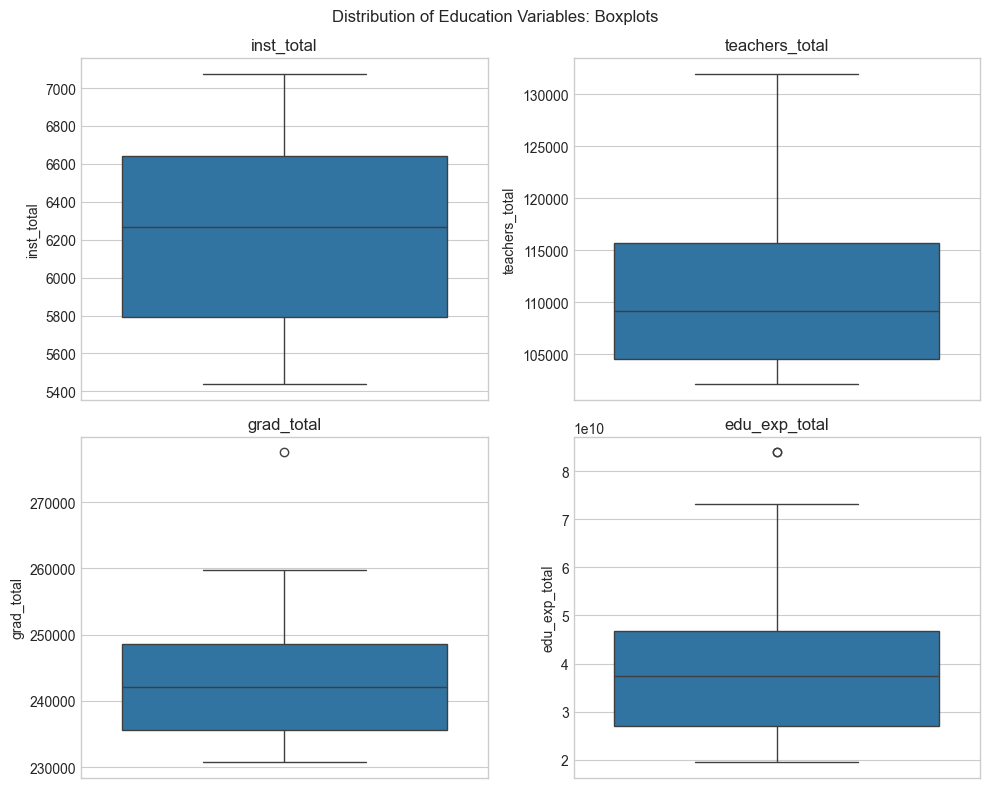

In [584]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(education_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle('Distribution of Education Variables: Boxplots')
plt.tight_layout()
plt.show()

Most variables are right-skewed, likely because economic values stayed low for a long time. Growth is probably a recent trend.

However, there are three exceptions:
- Birth counts follow a normal distribution because they are shaped by many small, random influences that cancel each other.

- Unemployment rate is the "mirror image" of the others. While, for example, GDP shows growth by climbing from low to high, unemployment shows improvement by dropping from high to low. But the logic is the same.

- Educational facilities show a bimodal pattern because they are driven by government planning rather than random growth. Instead of scaling naturally, they are built in fixed tiers to meet specific population needs in specific regions.

We will investigate the outliers in GDP, salary, education expenditure and graduation totals later; for now, we assume they represent a significant lead in recent times. We will check this, along with the assumption that growth is a recent trend, in the upcoming time series plots.

# Visualizations

## Time Series Plots

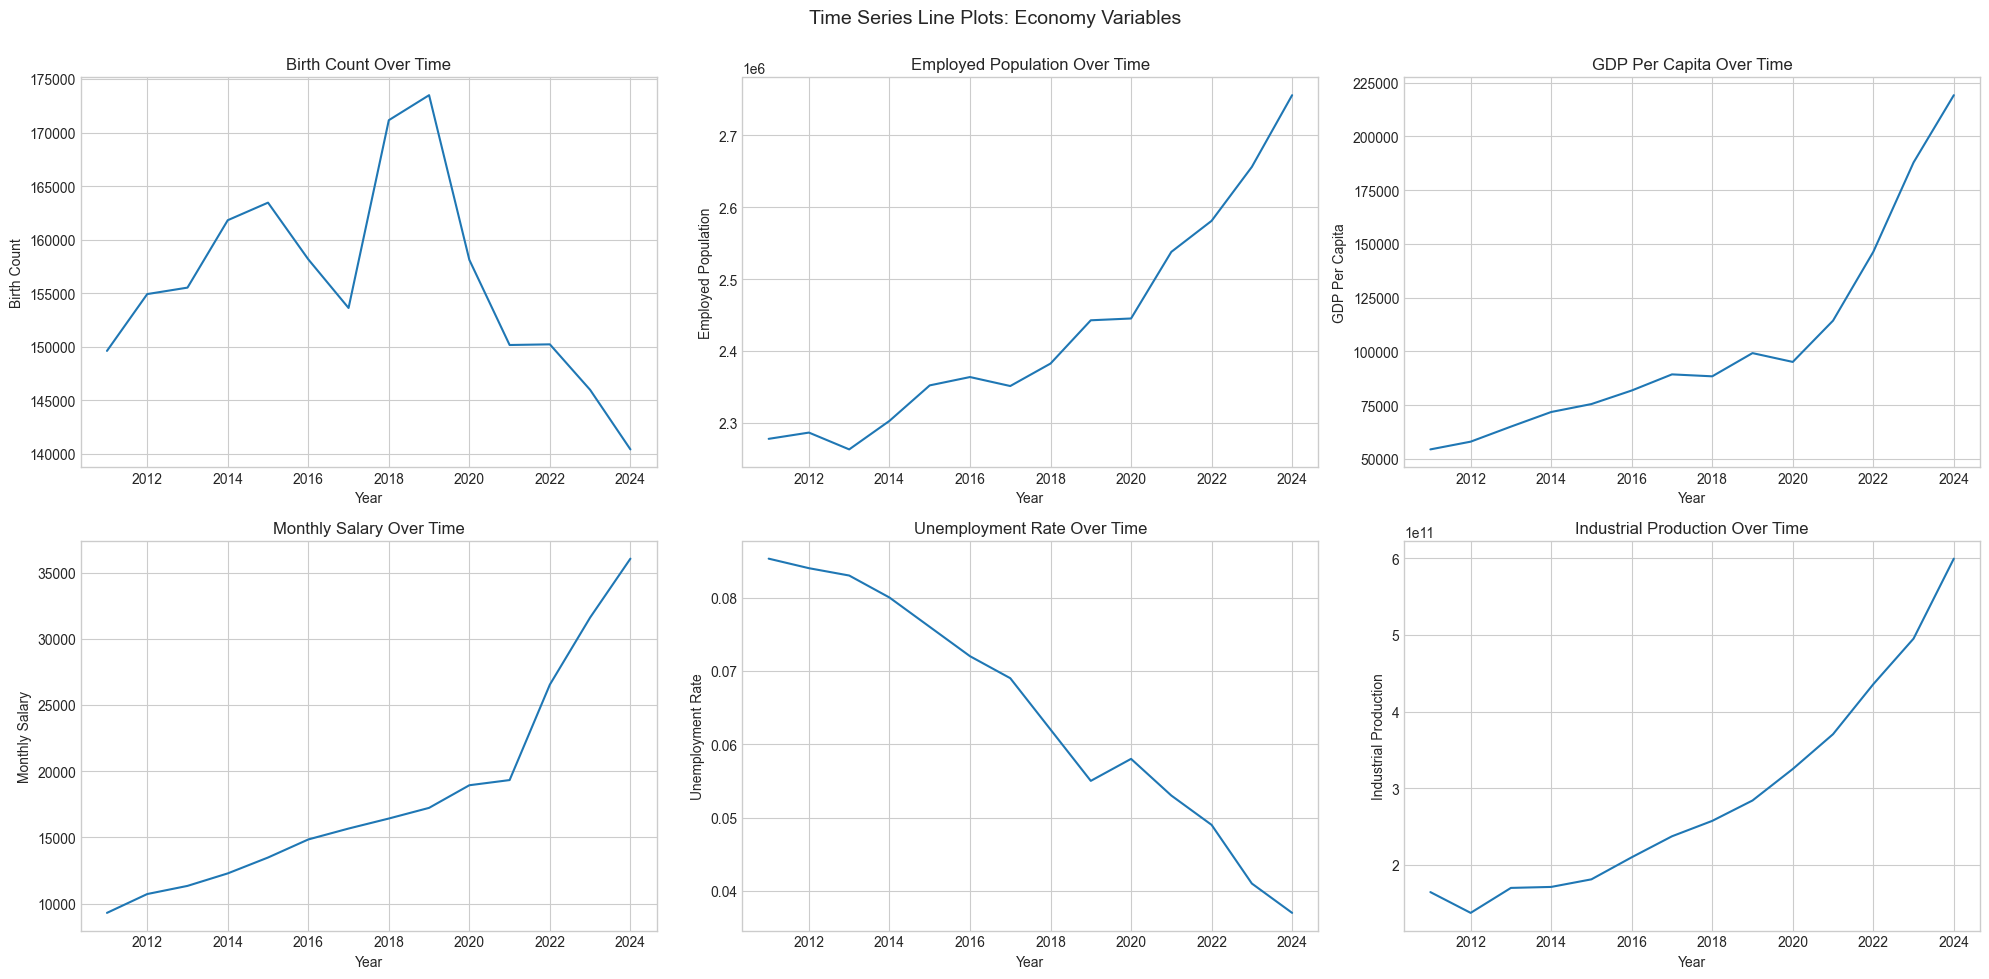

In [585]:
timeseries_eco_plot_configs = {
    'birth_count': {'title': 'Birth Count Over Time', 'ylabel': 'Birth Count'},
    'employed_population': {'title': 'Employed Population Over Time', 'ylabel': 'Employed Population'},
    'gdp_per_capita': {'title': 'GDP Per Capita Over Time', 'ylabel': 'GDP Per Capita'},
    'monthly_salary': {'title': 'Monthly Salary Over Time', 'ylabel': 'Monthly Salary'},
    'unemployment_rate': {'title': 'Unemployment Rate Over Time', 'ylabel': 'Unemployment Rate'},
    'industrial_production': {'title': 'Industrial Production Over Time', 'ylabel': 'Industrial Production'}
}

plt.figure(figsize=(20, 14))
for i, (col, config) in enumerate(timeseries_eco_plot_configs.items(), 1):
    plt.subplot(3, 3, i)
    sns.lineplot(x=df.index, y=df[col])
    plt.title(config['title'])
    plt.xlabel('Year')
    plt.ylabel(config['ylabel'])
plt.suptitle('Time Series Line Plots: Economy Variables', fontsize=14, y=1)
plt.tight_layout()
plt.show()

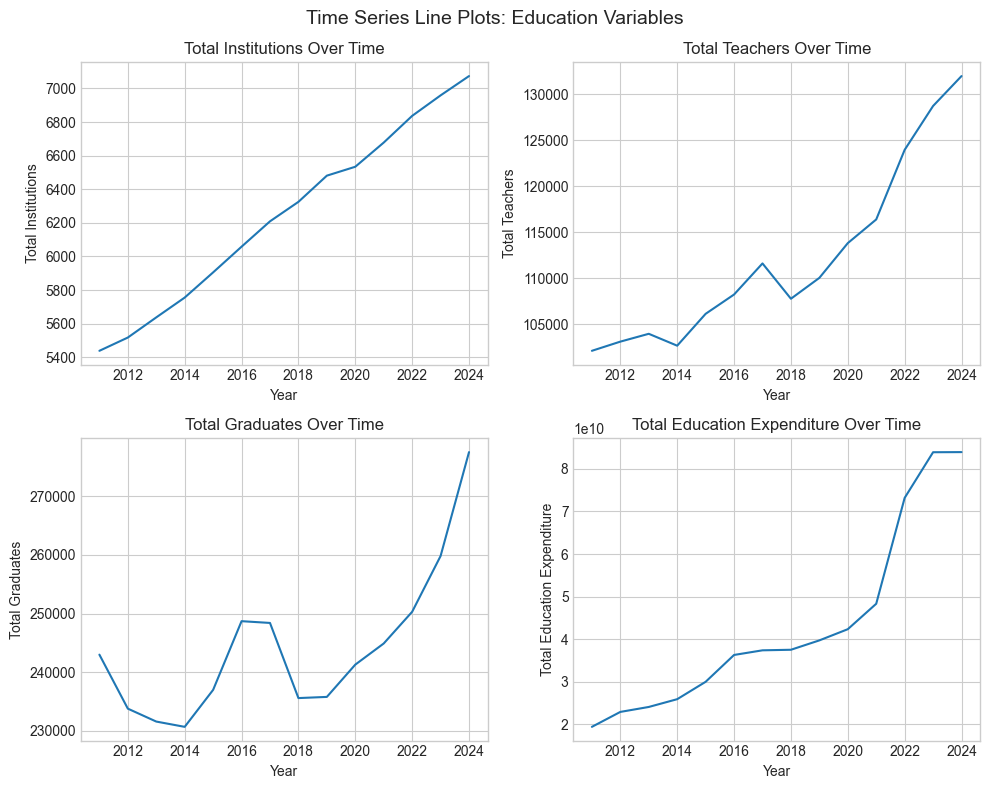

In [586]:
timeseries_edu_plot_configs = {
    'inst_total': {'title': 'Total Institutions Over Time', 'ylabel': 'Total Institutions'},
    'teachers_total': {'title': 'Total Teachers Over Time', 'ylabel': 'Total Teachers'},
    'grad_total': {'title': 'Total Graduates Over Time', 'ylabel': 'Total Graduates'},
    'edu_exp_total': {'title': 'Total Education Expenditure Over Time', 'ylabel': 'Total Education Expenditure'}
}

plt.figure(figsize=(10, 8))
for i, (col, config) in enumerate(timeseries_edu_plot_configs.items(), 1):
    plt.subplot(2, 2, i)
    sns.lineplot(x=df.index, y=df[col])
    plt.title(config['title'])
    plt.xlabel('Year')
    plt.ylabel(config['ylabel'])
plt.suptitle('Time Series Line Plots: Education Variables', fontsize=14)
plt.tight_layout()
plt.show()

The plots revealed that economy and education sectors are undergoing a period of rapid growth. Around 2021, both of them saw a huge, simultaneous jump:

- GDP per Capita, monthly paychecks, and industrial production all started growing extremely fast.

- The government starts spending much more on education, and the number of graduates (as well as teachers) spikes.

- Unemployment rate drops lowest (under 4%), and the number of employed people rapidly increases, reaching nearly 2.8 million.

But, in contrast to these trends, birth counts crash to a 13-year low. Additionally, despite the surge in spending, the construction of education institutions remained steadily positive throughout the entire period, showing no sudden spike.

## Composition of Education Expenditure by Level

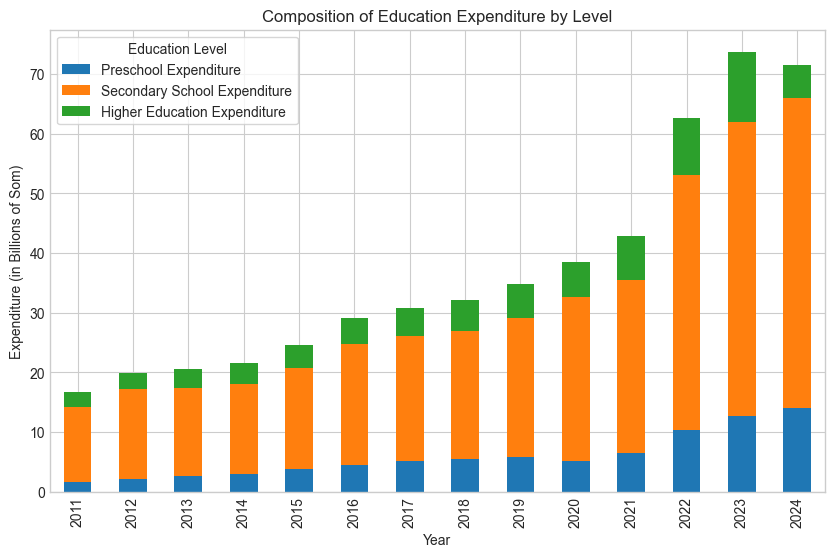

In [587]:
cols = ['edu_exp_preschool', 'edu_exp_secondary', 'edu_exp_higher']

(df[cols] / 1000000000).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Composition of Education Expenditure by Level')
plt.xlabel('Year')
plt.ylabel('Expenditure (in Billions of Som)')
plt.legend(['Preschool Expenditure', 'Secondary School Expenditure', 'Higher Education Expenditure'], 
           title='Education Level', 
           frameon=True)
plt.gca().ticklabel_format(axis='y', style='plain')
plt.show()

Total spending remained flat until 2021, then skyrocketed to over 70 billion som by 2024 — over four times the 2011 level. 

Despite this surge, the composition of spending stayed nearly identical throughout: secondary school consistently absorbed 70–80% of the budget, with preschool and higher education as minor shares. 

This means we are essentially looking at the same funding model scaled up — a useful baseline to keep in mind when interpreting any further trends.

## Education Expenditure vs. GDP per Capita

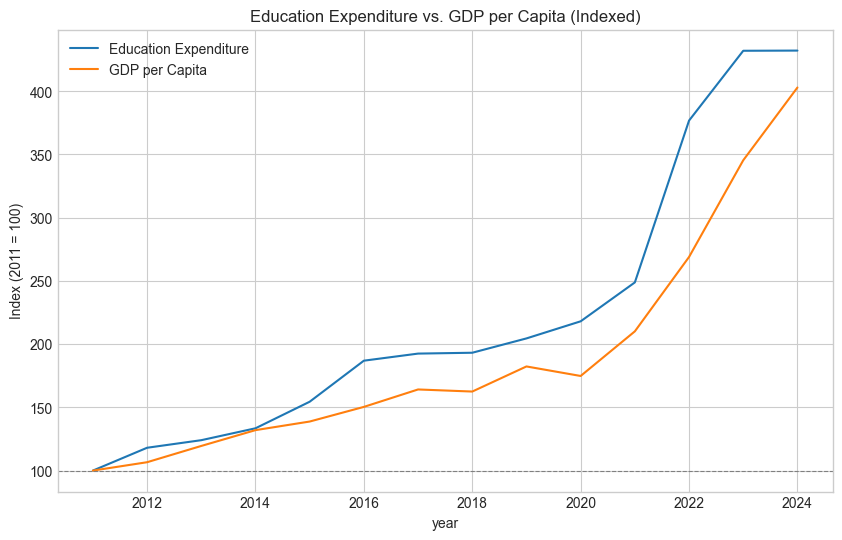

In [588]:
edu_base = df['edu_exp_total'].iloc[0]
gdp_base = df['gdp_per_capita'].iloc[0]

plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y=(df['edu_exp_total'] / edu_base) * 100, label='Education Expenditure')
sns.lineplot(x=df.index, y=(df['gdp_per_capita'] / gdp_base) * 100, label='GDP per Capita')
plt.axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel('Index (2011 = 100)')
plt.title('Education Expenditure vs. GDP per Capita (Indexed)')
plt.show()

Education expenditure grew faster than GDP per Capita across the entire period. Both variables moved closely together until around 2020, after which expenditure accelerated sharply.

Periods of GDP per Capita growth closely coincide with — or follow 2-3 years after — periods of rising education expenditure. By 2024, GDP per Capita largely caught up, with bot ending around 4-4.25x their 2011 baseline.

## Education Expenditure vs. Graduates with Cost per Graduate as Bubble Size

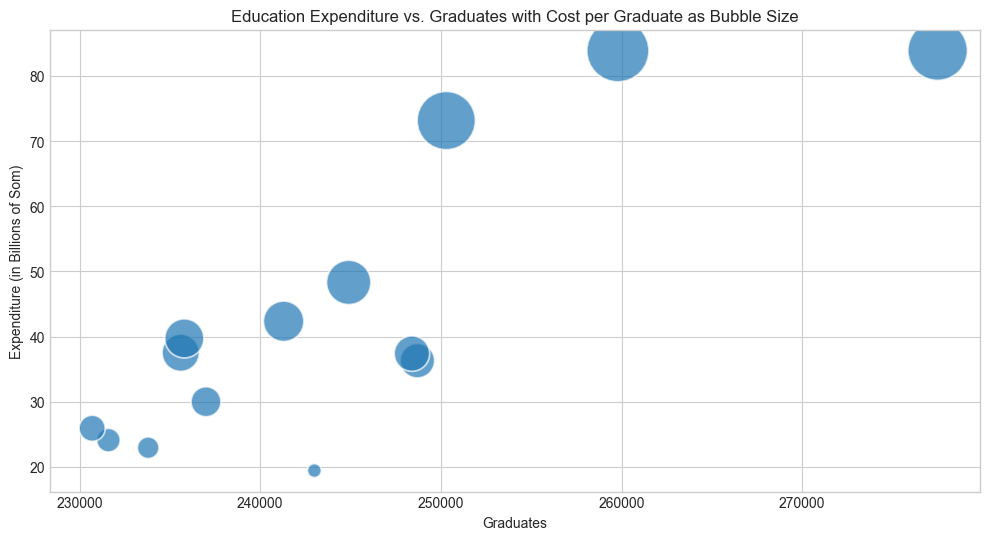

In [589]:
cost_per_grad = df['edu_exp_total'] / df['grad_total']

size_min, size_max = 100, 2000
size_norm = (cost_per_grad - cost_per_grad.min()) / (cost_per_grad.max() - cost_per_grad.min())
bubble_size = size_min + size_norm * (size_max - size_min)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=df['grad_total'], 
    y=df['edu_exp_total'] / 1000000000,
    s=bubble_size,
    sizes=(size_min, size_max),
    alpha=0.7
)
plt.gca().ticklabel_format(axis='y', style='plain')
plt.title('Education Expenditure vs. Graduates with Cost per Graduate as Bubble Size')
plt.xlabel('Graduates')
plt.ylabel('Expenditure (in Billions of Som)')
plt.show()

Generally speaking, as the number of graduates increases, education expenditure also rises. 

Larger bubbles at higher expenditure levels indicate that cost per graduate also tends to increase, but it is not consistent: similar number of graduates can have different bubble sizes.

## Graduates vs. Unemployment Rate & Employed Population

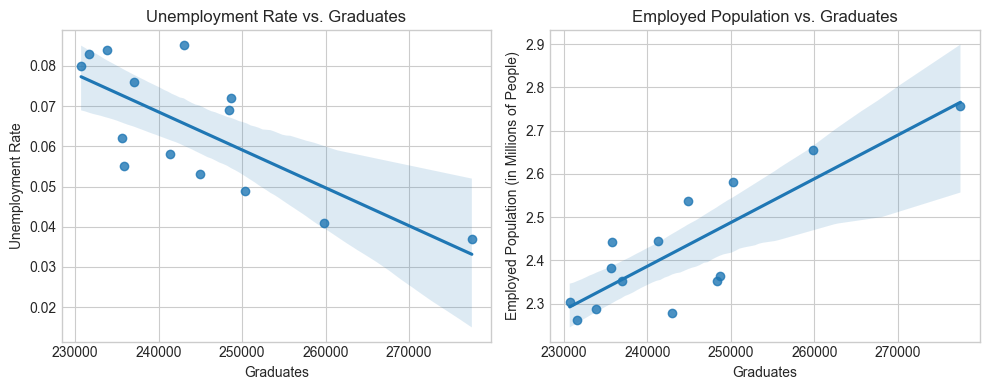

In [590]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.regplot(x=df['grad_total'], y=df['unemployment_rate'])
plt.title('Unemployment Rate vs. Graduates')
plt.xlabel('Graduates')
plt.ylabel('Unemployment Rate')

plt.subplot(1, 2, 2)
sns.regplot(x=df['grad_total'], y=df['employed_population'] / 1000000)
plt.title('Employed Population vs. Graduates')
plt.xlabel('Graduates')
plt.ylabel('Employed Population (in Millions of People)')

plt.tight_layout()
plt.show()

An increase in number of graduates is associated with a decrease in the unemployment rate and an increase in the employed population.

The first plot shows a negative relationship, the other a positive one. But both of them appear approximately linear, with some dispersion in data points.

# Correlation Analysis

In [591]:
edu_eco_corr = df[education_cols + economy_cols].corr()
edu_eco_corr

,inst_total,teachers_total,grad_total,edu_exp_total,birth_count,employed_population,gdp_per_capita,monthly_salary,unemployment_rate,industrial_production
inst_total,1.00,0.93,0.71,0.92,-0.30,0.94,0.89,0.92,-0.99,0.94
teachers_total,0.93,1.00,0.87,0.99,-0.60,0.98,0.98,0.99,-0.94,0.98
grad_total,0.71,0.87,1.00,0.84,-0.73,0.84,0.88,0.87,-0.74,0.85
edu_exp_total,0.92,0.99,0.84,1.00,-0.54,0.97,0.98,0.99,-0.93,0.97
birth_count,-0.30,-0.60,-0.73,-0.54,1.00,-0.52,-0.57,-0.54,0.32,-0.55
employed_population,0.94,0.98,0.84,0.97,-0.52,1.00,0.97,0.98,-0.96,0.99
gdp_per_capita,0.89,0.98,0.88,0.98,-0.57,0.97,1.00,0.99,-0.92,0.98
monthly_salary,0.92,0.99,0.87,0.99,-0.54,0.98,0.99,1.00,-0.94,0.98
unemployment_rate,-0.99,-0.94,-0.74,-0.93,0.32,-0.96,-0.92,-0.94,1.00,-0.96
industrial_production,0.94,0.98,0.85,0.97,-0.55,0.99,0.98,0.98,-0.96,1.00


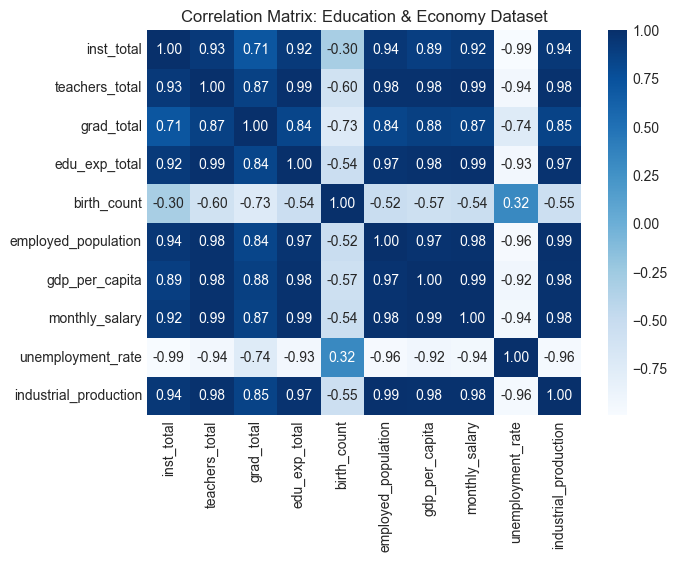

In [592]:
plt.figure(figsize=(7,5))
sns.heatmap(edu_eco_corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix: Education & Economy Dataset")
plt.show()

Nearly all education and economy variables are strongly positively correlated with each other (0.84–0.99), suggesting they all grow together over time.

`birth_count` is the clear outlier — it shows negative correlation with almost every other variable, meaning as the economy and education system expanded, birth rates declined.

`unemployment_rate` moves inversely to everything — as employment, salaries, GDP, and education expenditure grew, unemployment consistently fell.

`edu_exp_total` and `gdp_per_capita` are correlated at 0.98, consistent with the indexed chart finding that both variables track each other closely over the period.

# Hypothesis Test

We are testing `grad_total` and `employed_population` variables.

   - $H_0$: `grad_total` and `employed_population` are independent.
   - $H_1$: `grad_total` and `employed_population` are correlated.

In [593]:
r, p_value = stats.pearsonr(df['grad_total'], df['employed_population'])

print(f"r = {r:.4f}")
print(f"p-value = {p_value:.4f}")

if p_value < 0.05:
    print("The correlation is statistically significant. P-value < 0.05")
else:
    print("The correlation is not statistically significant. P-value >= 0.05")

r = 0.8440
p-value = 0.0001
The correlation is statistically significant. P-value < 0.05


Total graduates and employed population were examined for association using a Pearson correlation test. With r = 0.84 and p < 0.05, the null hypothesis of independence was rejected. The sample provides sufficient evidence that the two variables are correlated.

# Interpretation of Findings

Looking at key education and economy indicators in Kyrgyzstan, most variables remained relatively stable until 2021, when both sectors saw a sharp rise. By 2024, GDP per Capita and education expenditure had both grown roughly four times their 2011 values.

Over the same period, the number of teachers and graduates increased, while the number of institutions grew steadily throughout. Unemployment hit its lowest point, and employed population reached its peak. Much of this growth happened in sudden jumps rathen than gradually.

Regression analysis and correlation matrix confirmed very strong, predominantly positive relationships between education and economy indicators. But does this mean education directly caused economic growth — or is the picture more complicated?

We see three explanations possible, two of which appear unlikely. The first: education growth clearly preceded economic growth. The second: economic growth clearly preceded education growth. Both are naive and hard to support because most indicators move simultaneously — and education is a long-term investment, where reforms today may only show results in 5 to 10 years.

The more plausible explanation is that education and the economy act as mutual accelerators. A growing economy — driven by many different factors — demands a capable education system to sustain its growth. At the same time, education needs continued investment to keep pace with the economy, otherwise it cannot fulfill its role.

# Limitations

Making any claims about causal relationships between education and economy indicators is difficult in this case. Over the study period, many external factors influenced both sets of variables, which could significantly distort any conclusions.

Additionally, this study was limited to quntitative indicators — the most available ones. A fuller assessment of education's impact on the contry and its economy would require a qualitative evaluation of the education system. However, we were unable to find sufficient research and consistent data in this area, and we do not have the expertise to do this on our own.

# Conclusion

Education and economy indicators show strong correlations, but claiming causation would be overconfident given the external factors influencing both sets of variables.

In some cases, such as GDP per Capita and education expenditure, one indicator may appear to lead the other — however, the observed time gap never exceeded three years, which is too short to establish a causal relationship.

The most reasonable explanation is that education and the economy act as mutual accelerators, each needing to keep pace with the other in order to fulfill its role.